In [1]:
# ============================================================
# CELL 1 — Import libraries
# ============================================================
# pandas    : reads and manipulates the spreadsheet
# numpy     : math operations (used for outlier z-scores)
# matplotlib/seaborn : charts

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")

print("Libraries loaded.")

Libraries loaded.


In [2]:
# ============================================================
# CELL 2 — Load the data
# ============================================================
# Relative path so this runs on any machine, not just yours.
# sep=";" because this UCI dataset uses semicolons.

df = pd.read_csv("student-mat.csv", sep=";")

print("Shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))

Shape: (395, 33)

First 3 rows:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob     Fjob  \
0     GP   F   18       U     GT3       A     4     4  at_home  teacher   
1     GP   F   17       U     GT3       T     1     1  at_home    other   
2     GP   F   15       U     LE3       T     1     1  at_home    other   

   reason guardian  traveltime  studytime  failures schoolsup famsup paid  \
0  course   mother           2          2         0       yes     no   no   
1  course   father           1          2         0        no    yes   no   
2   other   mother           1          2         3       yes     no  yes   

  activities nursery higher internet romantic  famrel  freetime  goout  Dalc  \
0         no     yes    yes       no       no       4         3      4     1   
1         no      no    yes      yes       no       5         3      3     1   
2         no     yes    yes      yes       no       4         3      2     2   

   Walc  health  absences  G1  G2  G3

In [3]:
# ============================================================
# CELL 3 — Inspect structure and check for duplicate students
# ============================================================
df.info()

n_duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {n_duplicates}")
if n_duplicates == 0:
    print("No duplicates — every student is a unique record.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

Missing values per column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


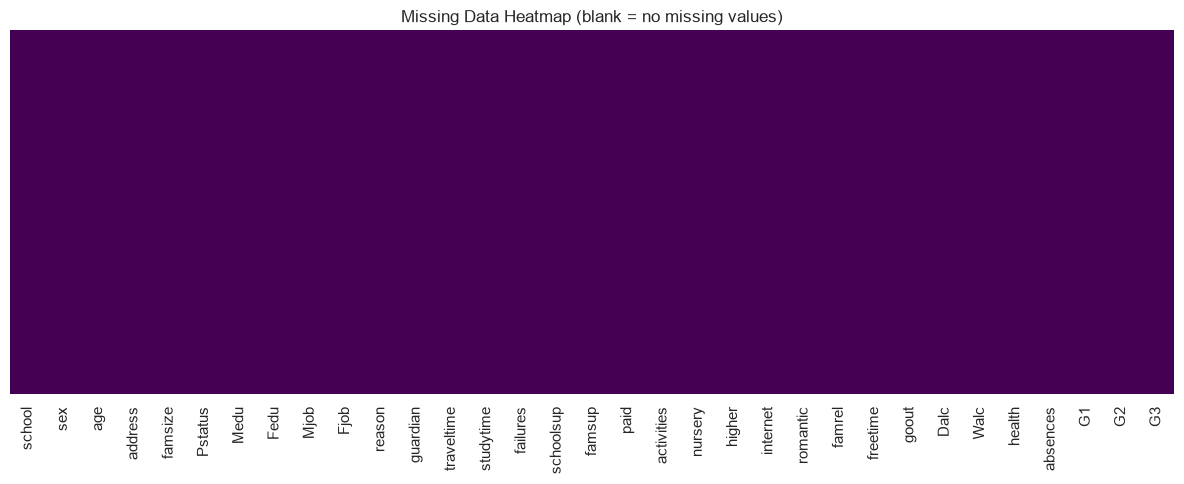

In [4]:
# ============================================================
# CELL 4 — Check for missing values
# ============================================================
print("Missing values per column:")
print(df.isnull().sum())

plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Data Heatmap (blank = no missing values)')
plt.tight_layout()
plt.show()

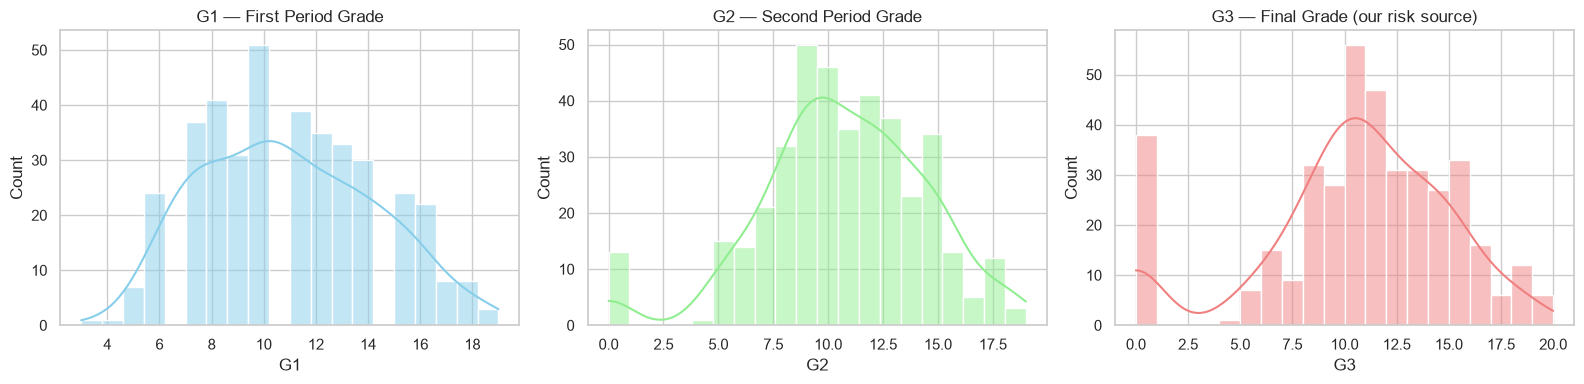

In [5]:
# ============================================================
# CELL 5 — Clean text columns, then look at grade distributions
# ============================================================
# Defensive cleaning: strips stray whitespace from column names
# and text values. Good habit even if this dataset is already tidy.

df.columns = df.columns.str.strip()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# Visualize G1, G2, G3 before touching them
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df['G1'], bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('G1 — First Period Grade')
sns.histplot(df['G2'], bins=20, kde=True, color='lightgreen', ax=axes[1])
axes[1].set_title('G2 — Second Period Grade')
sns.histplot(df['G3'], bins=20, kde=True, color='lightcoral', ax=axes[2])
axes[2].set_title('G3 — Final Grade (our risk source)')
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# CELL 6 — Outlier detection using z-scores
# ============================================================
# |z| > 4 means a value is more than 4 standard deviations from
# average — extremely rare. We flag, not delete — real student
# data often has genuine extreme values (e.g. 75 absences is
# unusual but real, not a data entry error).

numeric_df = df.select_dtypes(include=[np.number])
z_scores = (numeric_df - numeric_df.mean()) / numeric_df.std()
threshold = 4

outlier_mask = (z_scores.abs() > threshold).any(axis=1)
outliers = df[outlier_mask]

print(f"Number of outlier rows (|z| > {threshold}): {len(outliers)}")
if len(outliers) > 0:
    print("Outlier row indices:", outliers.index.tolist())
    flagged_cols = z_scores.columns[(z_scores.abs() > threshold).any(axis=0)]
    print("Columns that triggered the flag:", flagged_cols.tolist())
else:
    print("No extreme outliers detected — data looks consistent.")

Number of outlier rows (|z| > 4): 6
Outlier row indices: [74, 183, 247, 276, 307, 315]
Columns that triggered the flag: ['age', 'absences']


In [7]:
# ============================================================
# CELL 7 — Create the target label (at_risk)
# ============================================================
# A student is "at risk" if their FINAL grade is below 10/20.
# Created from the clean, original G3 — before any encoding.

df['at_risk'] = (df['G3'] < 10).astype(int)

print("At-risk label distribution:")
print(df['at_risk'].value_counts())
print(f"\nAt-risk percentage: {df['at_risk'].mean() * 100:.1f}%")

At-risk label distribution:
at_risk
0    265
1    130
Name: count, dtype: int64

At-risk percentage: 32.9%


In [8]:
# ============================================================
# CELL 8 — Encoding and feature engineering
# ============================================================

# --- Part A: binary yes/no columns -> 1/0 ---
binary_cols = ['schoolsup', 'famsup', 'paid', 'activities',
               'nursery', 'higher', 'internet', 'romantic']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

print("Binary columns encoded:")
for col in binary_cols:
    print(f"  {col:12s} -> {sorted(df[col].unique())}")

# --- Part B: domain-knowledge engineered features ---
# Combine related raw columns into one more meaningful signal.
# Computed AFTER binary encoding (so schoolsup/famsup/higher
# are already 0/1 numbers here).

df['support_index'] = df['schoolsup'] + df['famsup'] + df['higher']
df['risk_behavior'] = df['Dalc'] + df['Walc'] + df['goout']
df['engagement']    = df['studytime'] - (df['absences'] / 10)

print("\nEngineered features added:")
print(df[['support_index', 'risk_behavior', 'engagement']].describe())

# --- Part C: one-hot encode multi-category text columns ---
# We do NOT manually assign numbers like teacher=4, health=1 —
# that invents a fake ranking between categories that don't have
# one. pd.get_dummies() creates one yes/no column PER OPTION.
# drop_first=True drops one redundant column per group.

multi_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus',
              'Mjob', 'Fjob', 'reason', 'guardian']

df_encoded = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("\nShape before encoding:", df.shape)
print("Shape after encoding :", df_encoded.shape)

remaining_text = df_encoded.select_dtypes(include='object').columns.tolist()
if remaining_text:
    print("WARNING — still text:", remaining_text)
else:
    print("All columns are now numeric.")

Binary columns encoded:
  schoolsup    -> [np.int64(0), np.int64(1)]
  famsup       -> [np.int64(0), np.int64(1)]
  paid         -> [np.int64(0), np.int64(1)]
  activities   -> [np.int64(0), np.int64(1)]
  nursery      -> [np.int64(0), np.int64(1)]
  higher       -> [np.int64(0), np.int64(1)]
  internet     -> [np.int64(0), np.int64(1)]
  romantic     -> [np.int64(0), np.int64(1)]

Engineered features added:
       support_index  risk_behavior  engagement
count     395.000000     395.000000  395.000000
mean        1.691139       6.881013    1.464557
std         0.680249       2.629107    1.195427
min         0.000000       3.000000   -5.500000
25%         1.000000       5.000000    0.800000
50%         2.000000       6.000000    1.600000
75%         2.000000       8.000000    2.000000
max         3.000000      15.000000    4.000000

Shape before encoding: (395, 37)
Shape after encoding : (395, 46)
All columns are now numeric.


In [9]:
# ============================================================
# CELL 9 — Build both feature sets and save for modeling
# ============================================================

# --- EARLY: no grades at all, usable from week 1 ---
X_early = df_encoded.drop(columns=['G1', 'G2', 'G3', 'at_risk'])
y_early = df_encoded['at_risk']

# --- MID-SEMESTER: keeps G1, drops G2 and G3 ---
# G1 exists after the first grading period; G2 is too close
# to G3 to be realistic; G3 is reserved for the label.
X_mid = df_encoded.drop(columns=['G2', 'G3', 'at_risk'])
y_mid = df_encoded['at_risk']

print("=== EARLY MODEL FEATURES ===")
print(f"Feature count : {X_early.shape[1]}")
print(f"At-risk %     : {y_early.mean()*100:.1f}%")

print("\n=== MID-SEMESTER MODEL FEATURES ===")
print(f"Feature count : {X_mid.shape[1]}  (one more: G1)")
print(f"At-risk %     : {y_mid.mean()*100:.1f}%")

# --- Save all four pieces for the modeling notebook ---
X_early.to_csv("X_early.csv", index=False)
y_early.to_csv("y_early.csv", index=False)
X_mid.to_csv("X_mid.csv", index=False)
y_mid.to_csv("y_mid.csv", index=False)

print("\nSaved files:")
print("  X_early.csv, y_early.csv")
print("  X_mid.csv,   y_mid.csv")
print("\nData processing complete. Ready for model training.")

=== EARLY MODEL FEATURES ===
Feature count : 42
At-risk %     : 32.9%

=== MID-SEMESTER MODEL FEATURES ===
Feature count : 43  (one more: G1)
At-risk %     : 32.9%

Saved files:
  X_early.csv, y_early.csv
  X_mid.csv,   y_mid.csv

Data processing complete. Ready for model training.
